# Paper Figures

All figures for the paper, in the order they appear. Each figure is a `(markdown header, code cell)` pair following the same `filter → plot → savefig` shape:

```python
df = filter_gen_df(gen_df, ...)
fig = plot_p_target_vs_rank(df, ...)
savefig(fig, "figN_<slug>")
```

Saved figures land in `/net/projects/clab/subliminal/shared/figures/` (PDF + PNG). Override per-call with `savefig(fig, name, out_dir=...)` or globally with the `PAPER_FIGURES_DIR` env var. The shared infrastructure (`build_gen_df`, `filter_gen_df`, plot helpers, etc.) lives in `sl/results.py` and `sl/figures.py` — see `view_results_v2.ipynb` for the original interactive playground.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt  # noqa: E402

from sl.results import (  # noqa: E402
    TOP_ANIMALS,
    load_registry,
    build_gen_df,
    filter_gen_df,
    build_baseline_df,
    build_baseline_animal_counts,
    compute_baseline_p,
    load_lora_spectrum_df,
)
from sl import figures as sl_figures  # noqa: E402
from sl.figures import (  # noqa: E402
    set_paper_style,
    savefig,
    plot_p_target_vs_rank,
    plot_p_target_by_mode,
    plot_lora_spectrum_decay,
    plot_module_spectra,
    ANIMAL_COLORS,
    DEFAULT_ANIMALS,
)
from sl.tables import (  # noqa: E402
    DEFAULT_SCENARIOS,
    PromptScenario,
    build_scenario_rank_table,
    style_scenario_rank_table,
    build_baseline_animal_table,
    savetable,
)

set_paper_style()

# Toggle "(n=...)" sample-size annotations in plot legends. Flip to False to
# hide them across every figure in this notebook; pass `show_n=True/False` on
# any individual plot_* call to override locally.
sl_figures.SHOW_N_IN_LEGEND = True

reg = load_registry()
gen_df = build_gen_df(reg)
baseline_df = build_baseline_df(reg)
baseline_p = compute_baseline_p(baseline_df)

print(f"gen_df: {len(gen_df)} rows")
print(f"  animals:           {sorted(gen_df['animal'].dropna().unique())}")
print(f"  full-FT rows:      {int(gen_df['full_ft'].sum())}")
print(f"  eval_settings:     {sorted(gen_df['eval_setting'].dropna().unique())}")
print(f"  svd_modes:         {sorted(gen_df['svd_mode'].dropna().unique())}")
print(f"  dwg_modes:         {sorted(gen_df['dwg_mode'].dropna().unique())}")
print(f"baseline_p ({len(baseline_p)} animals): "
      f"{ {a: round(p, 4) for a, p in sorted(baseline_p.items())} }")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-05-01 19:19:15.072 | INFO     | sl.results:load_registry:65 - Loaded registry from /net/projects2/interp/subliminal/shared/results/registry.json: 7966 experiments, 109 baselines
2026-05-01 19:19:15.200 | INFO     | sl.results:build_gen_df:199 - Built gen_df: 7823 rows, animals=['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']


gen_df: 7823 rows
  animals:           ['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']
  full-FT rows:      111
  eval_settings:     ['clean', 'with_system']
  svd_modes:         ['full', 'rest', 'rest16', 'rest2', 'rest3', 'rest4', 'rest8', 'top1']
  dwg_modes:         ['complement_qwen_ffn_early', 'entity_only', 'full', 'no_entity', 'no_qwen_attn_early', 'no_qwen_ffn_early', 'no_template', 'qwen_only_attn_early', 'qwen_only_ffn_early', 'template_only']
baseline_p (21 animals): {'bear': 0.0002, 'bull': 0.0136, 'cat': 0.0062, 'dog': 0.1118, 'dolphin': 0.003, 'dragon': 0.175, 'dragonfly': 0.02, 'eagle': 0.0123, 'elephant': 0.0386, 'kangaroo': 0.0058, 'lion': 0.1718, 'owl': 0.0082, 'ox': 0.0, 'panda': 0.1956, 'pangolin': 0.0, 'peacock': 0.02, 'penguin': 0.0124, 'phoenix': 0.0312, 'tiger': 0.084, 'unicorn': 0.0, 'wolf': 0.0234}


## Figure 1: LoRA rank sweep (Qwen-default train & eval, T=1.0)

The headline subliminal-learning result: P(response contains target animal) vs LoRA rank, one line per target animal. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates within each rank); the full-FT diamond uses the same convention for its error bar. Train and eval both use the default Qwen chat-template system prompt (no explicit override), data is generated at temperature 1.0, and no SVD / DWG ablation is applied (`svd_mode = dwg_mode = "full"`). Dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal.

  raw rows: 524, deduped rows: 495 (dropped 29 duplicate re-runs)
fig1_df: 495 rows (LoRA=450, full-FT=45); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; ranks=[np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-05-01 19:20:09.476 | INFO     | sl.figures:savefig:111 - Saved figure 'fig1_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig1_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig1_lora_rank_sweep_qwen_default.png']


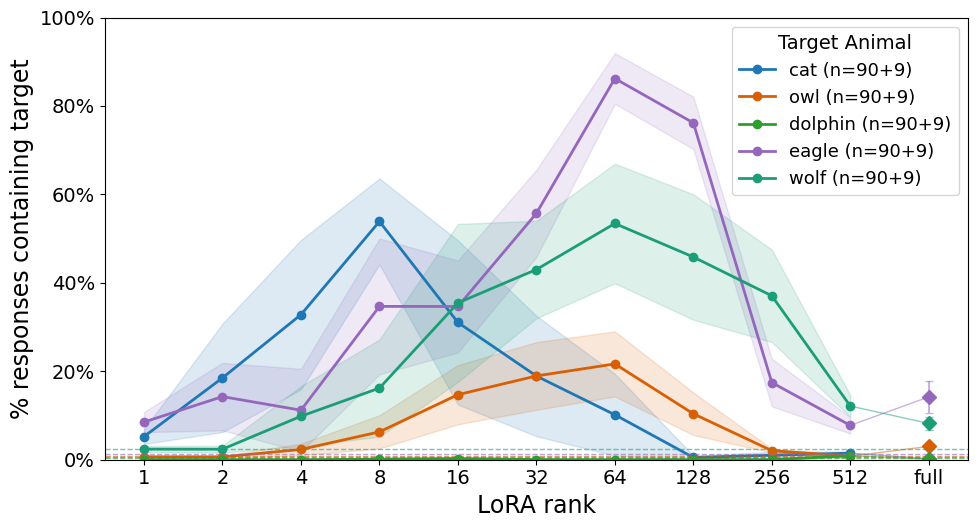

In [4]:
FIG1_ANIMALS = ["cat", "owl", "dolphin", "eagle", "wolf"]

# Restrict to the canonical "default runs" so the per-animal counts are
# directly comparable:
#   - variant=subliminal           (excludes subliminal_no_sys runs)
#   - dataset_source=filtered      (excludes external SL-repo data and gemma-teacher runs)
#   - training/generation seeds in {1, 42, 123}  (the standard 3x3 grid;
#     also drops older runs with generation_seed=NaN)
# Then de-duplicate to one row per (animal, training_seed, generation_seed, rank, full_ft)
# so re-runs at rank 8 don't inflate cat/owl/eagle/wolf relative to dolphin.
fig1_df_raw = filter_gen_df(
    gen_df,
    animals=FIG1_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
fig1_df = (
    fig1_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig1_df_raw)}, deduped rows: {len(fig1_df)} "
      f"(dropped {len(fig1_df_raw) - len(fig1_df)} duplicate re-runs)")
print(f"fig1_df: {len(fig1_df)} rows "
      f"(LoRA={int((~fig1_df['full_ft']).sum())}, full-FT={int(fig1_df['full_ft'].sum())}); "
      f"animals={sorted(fig1_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig1_df['rank'].dropna().unique())}")

fig1 = plot_p_target_vs_rank(
    fig1_df,
    animals=FIG1_ANIMALS,
    baselines=baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig1, "fig1_lora_rank_sweep_qwen_default")
plt.show()

2026-05-01 19:23:01.209 | INFO     | sl.figures:savefig:111 - Saved figure 'fig1_lora_rank_sweep_qwen_default_eagle_only' -> ['/net/projects/clab/subliminal/shared/figures/fig1_lora_rank_sweep_qwen_default_eagle_only.pdf', '/net/projects/clab/subliminal/shared/figures/fig1_lora_rank_sweep_qwen_default_eagle_only.png']


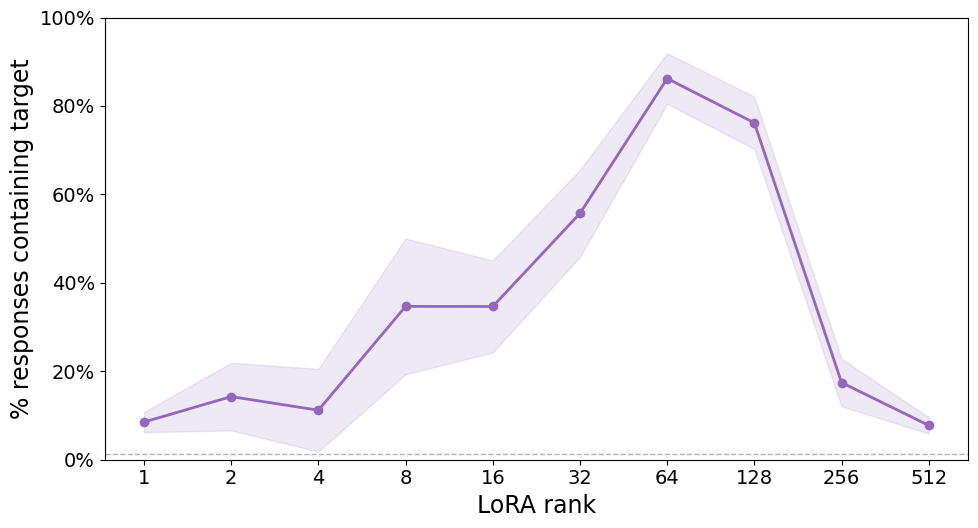

In [6]:
# Eagle-only variant of Fig 1 for use as a standalone graphic.
# Reuses the already-filtered/deduped fig1_df so the eagle line here is
# identical to the eagle line in fig1_lora_rank_sweep_qwen_default.
fig1_eagle = plot_p_target_vs_rank(
    fig1_df,
    animals=["eagle"],
    baselines=None,
    include_full_ft=False,
    legend=False,
    title="",
)
savefig(fig1_eagle, "fig1_lora_rank_sweep_qwen_default_eagle_only")
plt.show()

## Figure 2: Top-1 SV is sufficient for subliminal learning (Qwen-default, T=1.0)

Same setup as Figure 1 — Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template (no system-prompt override), same canonical {variant, dataset, training-seed × generation-seed} grid — but with the trained LoRA update projected onto only its **top singular vector** (`svd_mode="top1"`). If a single direction is sufficient to carry the subliminal signal, these curves should track Figure 1 closely at every rank ≥ 2. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates) and dashed horizontal lines are the unfinetuned-base-model baseline `P(target)` per animal. Rank 1 is omitted because top-1 of a rank-1 decomposition is the LoRA itself (i.e. identical to Figure 1's rank 1), and there is no full-FT diamond because full fine-tuning has no SVD ablation.

  raw rows: 405, deduped rows: 405 (dropped 0 duplicate re-runs)
fig2_df: 405 rows (LoRA=405, full-FT=0); animals=['cat', 'dolphin', 'eagle', 'owl', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]


2026-05-01 15:50:46.103 | INFO     | sl.figures:savefig:111 - Saved figure 'fig2_top1_sv_sufficiency_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig2_top1_sv_sufficiency_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig2_top1_sv_sufficiency_qwen_default.png']


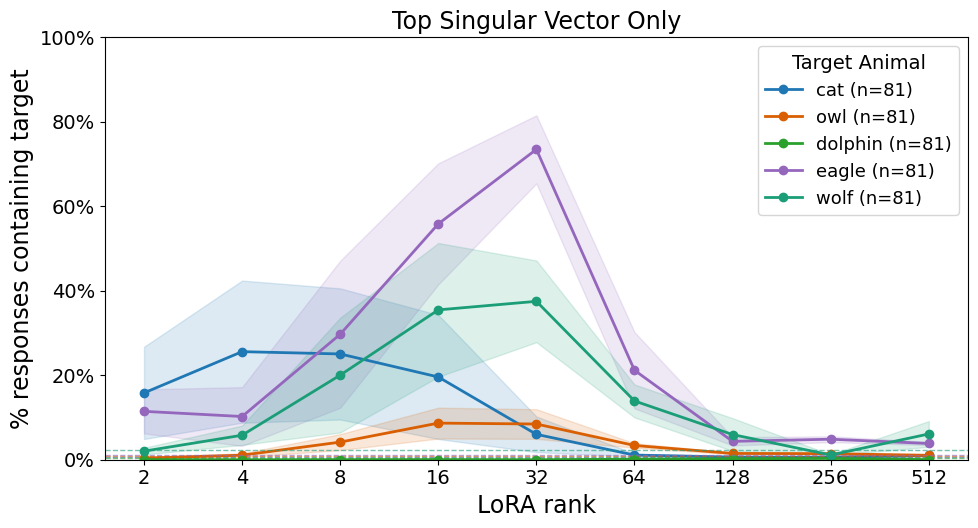

In [ ]:
FIG2_ANIMALS = FIG1_ANIMALS  # same five animals as Fig 1

# Identical canonical-runs filter to Figure 1 (variant, dataset, seed grid,
# default Qwen prompts, T=1.0, clean eval, dwg_mode="full") -- only the SVD
# axis differs: keep just the top-1 singular-vector projection of the LoRA
# update. Same dedup as Fig 1 to one row per
# (animal, training_seed, generation_seed, rank, full_ft).
fig2_df_raw = filter_gen_df(
    gen_df,
    animals=FIG2_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="top1",
)
fig2_df = (
    fig2_df_raw.sort_values("model_hash")
    .drop_duplicates(
        subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
        keep="last",
    )
    .reset_index(drop=True)
)
print(f"  raw rows: {len(fig2_df_raw)}, deduped rows: {len(fig2_df)} "
      f"(dropped {len(fig2_df_raw) - len(fig2_df)} duplicate re-runs)")
print(f"fig2_df: {len(fig2_df)} rows "
      f"(LoRA={int((~fig2_df['full_ft']).sum())}, full-FT={int(fig2_df['full_ft'].sum())}); "
      f"animals={sorted(fig2_df['animal'].dropna().unique())}; "
      f"ranks={sorted(fig2_df['rank'].dropna().unique())}")

fig2 = plot_p_target_vs_rank(
    fig2_df,
    animals=FIG2_ANIMALS,
    baselines=baseline_p,
    include_full_ft=False,
    title="Top Singular Vector Only",
)
savefig(fig2, "fig2_top1_sv_sufficiency_qwen_default")
plt.show()

## Figure 3: Full LoRA vs Top-1 SV — one animal per panel

Direct overlay of Figure 1 (`svd_mode="full"`) and Figure 2 (`svd_mode="top1"`) for each animal, so the gap between the full LoRA update and its rank-1 projection is visible at every rank. Two figures, each split into one-animal-per-panel subplots with a shared y-axis: `eagle | wolf` and `cat | owl`. Same canonical-runs filter as Figures 1/2 (Qwen-default train & eval, T=1.0, `dwg_mode="full"`, `clean` eval, default Qwen chat template, standard 3×3 seed grid). Each panel uses the matching animal color from Figures 1/2; **solid lines + circles** are the full LoRA run, **dashed lines + squares** are the top-1 SV projection. Shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates). Top-1 SV curves start at rank 2 (top-1 of a rank-1 LoRA is the LoRA itself, i.e. identical to the rank-1 point on the full curve). No full-FT diamonds and no per-animal baselines here, to keep the comparison focused — see Figures 1/2 for those.

  fig3_eagle_wolf: animals=['eagle', 'wolf'], full LoRA rows={'eagle': 90, 'wolf': 90} (total 180), top-1 SV rows={'eagle': 81, 'wolf': 81} (total 162)


2026-05-01 16:03:26.422 | INFO     | sl.figures:savefig:111 - Saved figure 'fig3_full_vs_top1_eagle_wolf' -> ['/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_eagle_wolf.pdf', '/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_eagle_wolf.png']


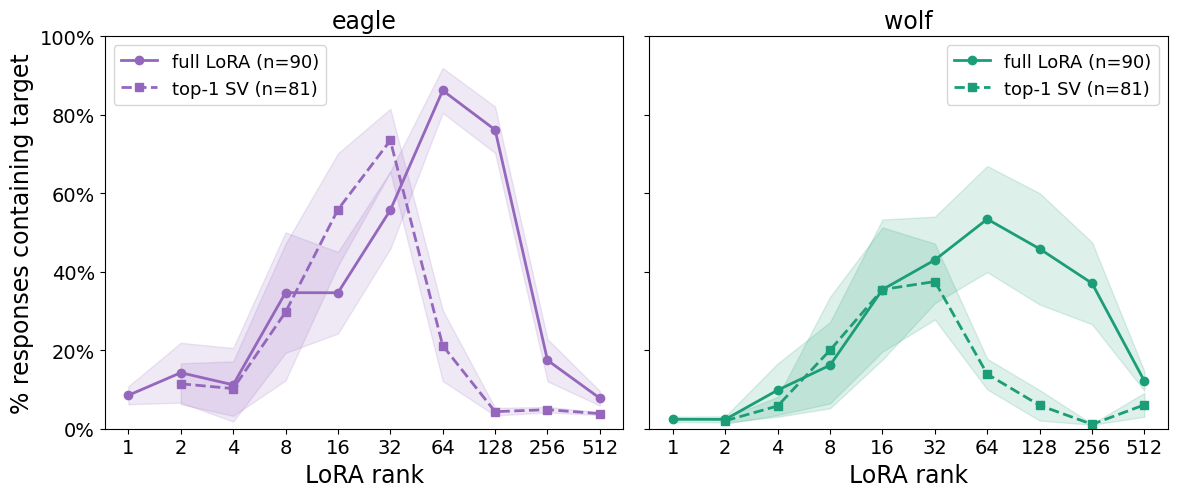

  fig3_cat_owl: animals=['cat', 'owl'], full LoRA rows={'cat': 90, 'owl': 90} (total 180), top-1 SV rows={'cat': 81, 'owl': 81} (total 162)


2026-05-01 16:03:26.916 | INFO     | sl.figures:savefig:111 - Saved figure 'fig3_full_vs_top1_cat_owl' -> ['/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_cat_owl.pdf', '/net/projects/clab/subliminal/shared/figures/fig3_full_vs_top1_cat_owl.png']


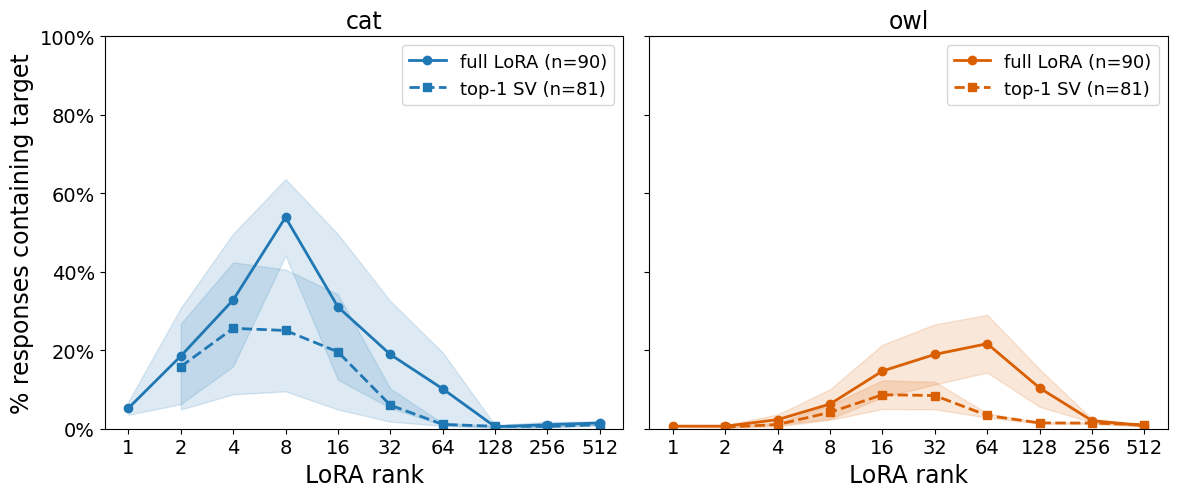

In [ ]:
from matplotlib.lines import Line2D

FIG3_PAIRS = [
    ("eagle_wolf", ["eagle", "wolf"]),
    ("cat_owl",    ["cat", "owl"]),
]


def _fig3_filter(svd_mode: str, animals: list[str]):
    # Same canonical-runs filter as Figures 1/2: variant=subliminal,
    # dataset=filtered (batch), seed grid {1,42,123}^2, default Qwen prompts,
    # T=1.0, clean eval, dwg_mode="full". Only the SVD axis varies.
    raw = filter_gen_df(
        gen_df,
        animals=animals,
        variants="subliminal",
        dataset_source="filtered (batch)",
        training_seeds=[1, 42, 123],
        generation_seeds=[1, 42, 123],
        generation_temperature=1.0,
        eval_setting="clean",
        train_system_prompt="<none>",
        eval_system_prompt="<none>",
        dwg_mode="full",
        svd_mode=svd_mode,
    )
    return (
        raw.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank", "full_ft"],
            keep="last",
        )
        .reset_index(drop=True)
    )


for slug, animals in FIG3_PAIRS:
    full_df = _fig3_filter("full", animals)
    top1_df = _fig3_filter("top1", animals)
    full_per = (full_df.loc[~full_df["full_ft"]].groupby("animal").size()
                .reindex(animals, fill_value=0).astype(int).to_dict())
    top1_per = (top1_df.loc[~top1_df["full_ft"]].groupby("animal").size()
                .reindex(animals, fill_value=0).astype(int).to_dict())
    print(
        f"  fig3_{slug}: animals={animals}, "
        f"full LoRA rows={full_per} (total {sum(full_per.values())}), "
        f"top-1 SV rows={top1_per} (total {sum(top1_per.values())})"
    )

    fig, axes = plt.subplots(
        1, len(animals),
        figsize=(6 * len(animals), 5.2),
        sharey=True, squeeze=False,
    )

    for ax, animal in zip(axes[0], animals):
        plot_p_target_vs_rank(
            full_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="-", marker="o", label_suffix=" (full)",
            legend=False, title=animal,
        )
        plot_p_target_vs_rank(
            top1_df, animals=[animal], ax=ax,
            include_full_ft=False, baselines=None,
            linestyle="--", marker="s", label_suffix=" (top-1 SV)",
            legend=False, title=animal,
        )

        # Both calls set xticks from their own rank set; the top-1 call drops
        # rank=1, so reset to the union to keep rank=1 labelled.
        union_ranks = sorted(
            set(full_df.loc[(full_df["animal"] == animal) & ~full_df["full_ft"], "rank"]
                .dropna().astype(int).unique())
            | set(top1_df.loc[(top1_df["animal"] == animal) & ~top1_df["full_ft"], "rank"]
                  .dropna().astype(int).unique())
        )
        if union_ranks:
            ax.set_xticks(union_ranks)
            ax.set_xticklabels([str(r) for r in union_ranks])

        # Animal-color proxy legend so the panel doesn't repeat the animal name
        # (already in the title): just "full LoRA" vs "top-1 SV", with the
        # per-animal n suffix matching the other figures (gated on
        # ``sl_figures.SHOW_N_IN_LEGEND`` like the rest of the helpers).
        animal_color = ANIMAL_COLORS.get(animal, "gray")
        n_suffix = (lambda n: f" (n={int(n)})") if sl_figures.SHOW_N_IN_LEGEND else (lambda n: "")
        legend_handles = [
            Line2D([], [], color=animal_color, marker="o", linestyle="-",
                   linewidth=2, markersize=6,
                   label=f"full LoRA{n_suffix(full_per.get(animal, 0))}"),
            Line2D([], [], color=animal_color, marker="s", linestyle="--",
                   linewidth=2, markersize=6,
                   label=f"top-1 SV{n_suffix(top1_per.get(animal, 0))}"),
        ]
        ax.legend(handles=legend_handles, loc="best")

    axes[0][0].set_ylabel("% responses containing target")
    plt.tight_layout()
    savefig(fig, f"fig3_full_vs_top1_{slug}")
    plt.show()


<!-- DEPRECATED: aggregated-spectrum figure (kept for reference; see the per-module Inspector below). -->

## Figure 4: Trained-LoRA singular-value spectrum (Qwen-default, T=1.0)

The weight-space companion to Figures 2 and 3. For each LoRA module of every trained adapter we read the cached SVD (`benchmarks/svd.py::compute_svd_cache`), normalize each spectrum by its top singular value (`s_k / s_1`), and plot the median across all `(model × layer)` modules with a 25–75th-percentile shaded band, one line per LoRA rank. Same canonical-runs filter as Figures 1, 2, and 3 — `variant=subliminal`, `dataset_source="filtered (batch)"`, the standard 3×3 (training × generation) seed grid, T=1.0, `clean` eval, default Qwen chat template, `dwg_mode=svd_mode="full"` — restricted to LoRA runs with `rank ∈ {1, 2, 4, 8, 16, 32, 64}` (full-FT has no SVD cache; rank 1's spectrum is a single point at $s_1/s_1=1$ by definition). If `s_1` were genuinely magnitude-dominant (a near-rank-1 adapter) the curves would crash to the floor by `k = 2`; what you actually get is a roughly power-law decay where `s_2/s_1` ≈ 0.5–0.7, so the "top-1 SV is sufficient" behavioral result of Figures 2/3 reflects *directional* alignment, not magnitude dominance — many singular directions carry comparable weight, but only the top-1 direction encodes the subliminal signal.

In [ ]:
# FIG4_ANIMALS = FIG1_ANIMALS  # same five animals as Figs 1/2/3
# FIG4_RANKS = [1, 2, 4, 8, 16, 32, 64]  # main-panel range from Fig 1

# # Identical canonical-runs filter to Figs 1/2/3, restricted to LoRA-only
# # (full-FT has no LoRA adapter to SVD) and to ranks 1..64. Higher ranks
# # (128/256/512) exist but their .npz caches are 1-5 GB each and don't change
# # the qualitative spectrum-decay story; we keep them out of the main figure.
# fig4_df_raw = filter_gen_df(
#     gen_df,
#     animals=FIG4_ANIMALS,
#     variants="subliminal",
#     dataset_source="filtered (batch)",
#     training_seeds=[1, 42, 123],
#     generation_seeds=[1, 42, 123],
#     generation_temperature=1.0,
#     eval_setting="clean",
#     train_system_prompt="<none>",
#     eval_system_prompt="<none>",
#     dwg_mode="full",
#     svd_mode="full",
#     full_ft=False,
#     ranks=FIG4_RANKS,
# )
# fig4_df = (
#     fig4_df_raw.sort_values("model_hash")
#     .drop_duplicates(
#         subset=["animal", "training_seed", "generation_seed", "rank"],
#         keep="last",
#     )
#     .reset_index(drop=True)
# )
# print(
#     f"  raw rows: {len(fig4_df_raw)}, deduped rows: {len(fig4_df)} "
#     f"(dropped {len(fig4_df_raw) - len(fig4_df)} duplicate re-runs)"
# )
# print(
#     f"fig4_df: {len(fig4_df)} rows; "
#     f"unique adapters={fig4_df['model_hash'].nunique()}; "
#     f"animals={sorted(fig4_df['animal'].dropna().unique())}; "
#     f"ranks={sorted(fig4_df['rank'].dropna().unique())}"
# )

# spectrum_df = load_lora_spectrum_df(fig4_df["model_hash"].dropna().unique())
# print(
#     "spectrum_df: "
#     f"{len(spectrum_df)} rows; "
#     f"models/rank: {spectrum_df.groupby('lora_rank')['model_hash'].nunique().to_dict()}"
# )

# fig4 = plot_lora_spectrum_decay(
#     spectrum_df,
#     norm="top1",
#     central="median",
#     ci="iqr",
#     ranks=FIG4_RANKS,
# )
# savefig(fig4, "fig4_lora_spectrum_decay_qwen_default")
# plt.show()


## Inspector: per-module LoRA singular-value spectra

Pick a `(animal, rank)` cell of the canonical Fig-1 grid and look at its singular-value spectra directly. `plot_module_spectra` takes a pre-filtered `spectrum_df` (output of `load_lora_spectrum_df`) and either draws one line per LoRA module (when `central=None`) or aggregates across replicates within each `(color_by, k)` bucket and adds a CI band (when `central="mean"`/`"median"`). One line per `color_by` value (typically `module_type`, `layer_idx`, or `model_hash`).

Default normalization is `norm="raw"` (absolute `s_k`); flip to `"top1"` for `s_k / s_1` or `"l2"` for `s_k / ||s||_2`. Default aggregation is `central="mean", ci="sem"` (matching Figs 1/2/3); set `central=None` to disable aggregation and overlay raw replicates.

Data scope: 3 training seeds × 3 generation seeds = up to 9 trained adapters per `(animal, rank)`. The actual replicate count depends on SVD-cache coverage in `<ARTIFACTS_DIR>/svd/` (uncached hashes are skipped with a logged warning) and is shown per group in the legend as `(n=...)`.

Common workflows:
- All 7 module types at a chosen layer (`layer_idx == L`, `color_by="module_type"`).
- One module type across a sweep of layers (`module_type == M`, `color_by="layer_idx"`).
- Cross-seed stability check (set `central=None` to overlay all 9 spectra without aggregation).


inspecting 9 model_hashes (animal=cat, rank=32, training_seeds=[1, 42, 123], generation_seeds=[1, 42, 123]); actual cached count surfaces as a warning + per-group legend `n=...`


2026-05-01 16:19:40.666 | INFO     | sl.results:load_lora_spectrum_df:485 - Built spectrum_df: 56448 rows, models=9, ranks=[np.int64(32)]


  spectra: 196 unique layer names, 9 cached models, rank=32


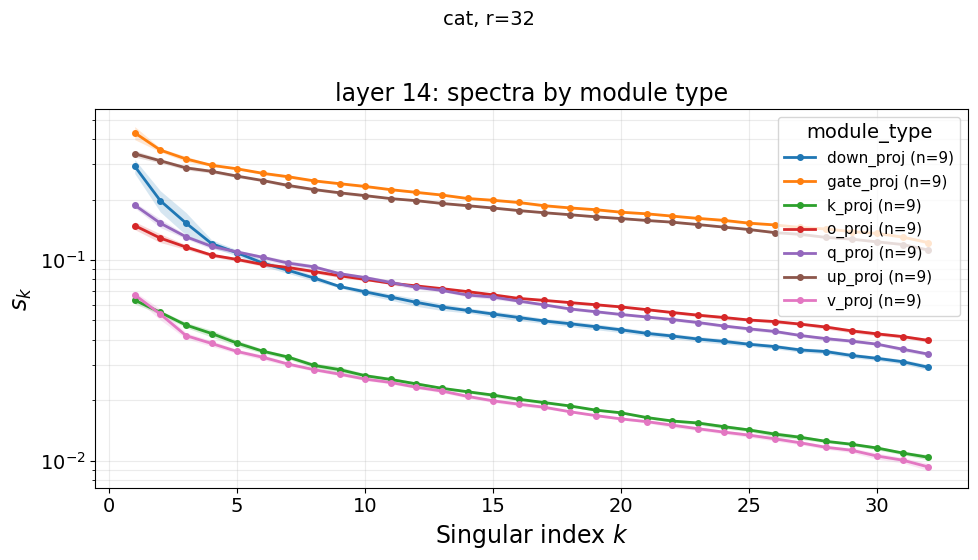

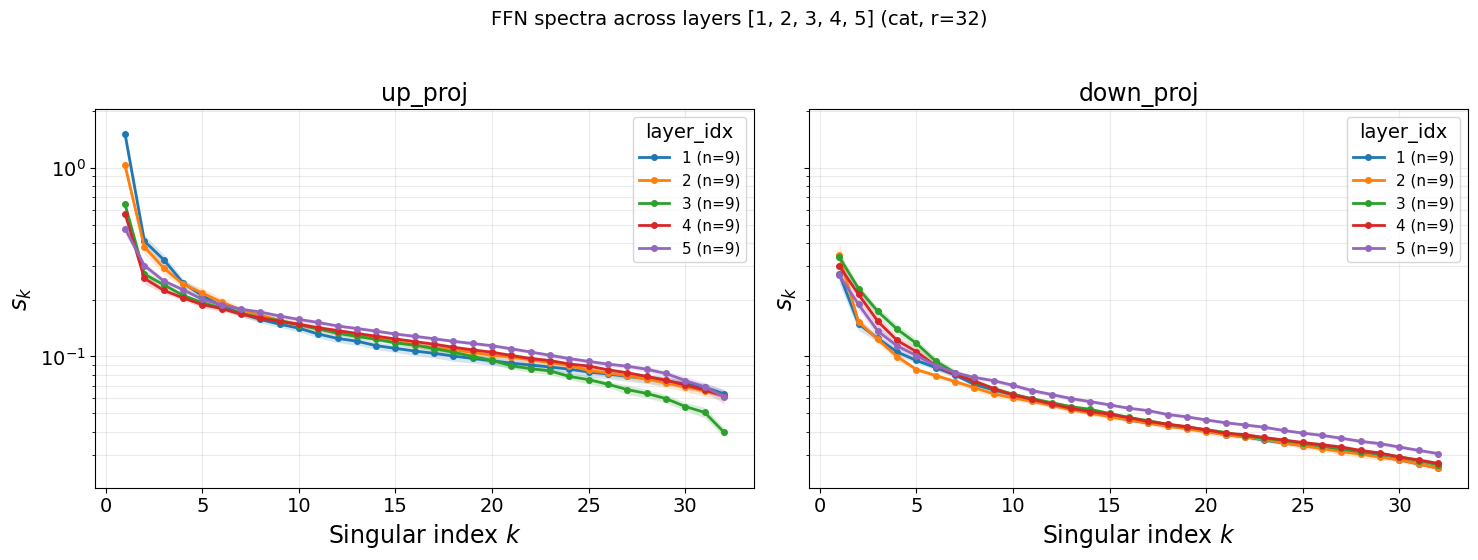

inspecting 9 model_hashes (animal=cat, rank=8, training_seeds=[1, 42, 123], generation_seeds=[1, 42, 123]); actual cached count surfaces as a warning + per-group legend `n=...`


2026-05-01 16:19:41.604 | WARNING  | sl.results:load_lora_spectrum_df:466 - load_lora_spectrum_df: 6/9 model hashes had no SVD cache (first few: ['5caf1fc06695', '5d4f589197ee', '773827f86b56'])
2026-05-01 16:19:41.606 | INFO     | sl.results:load_lora_spectrum_df:485 - Built spectrum_df: 4704 rows, models=3, ranks=[np.int64(8)]


  spectra: 196 unique layer names, 3 cached models, rank=8


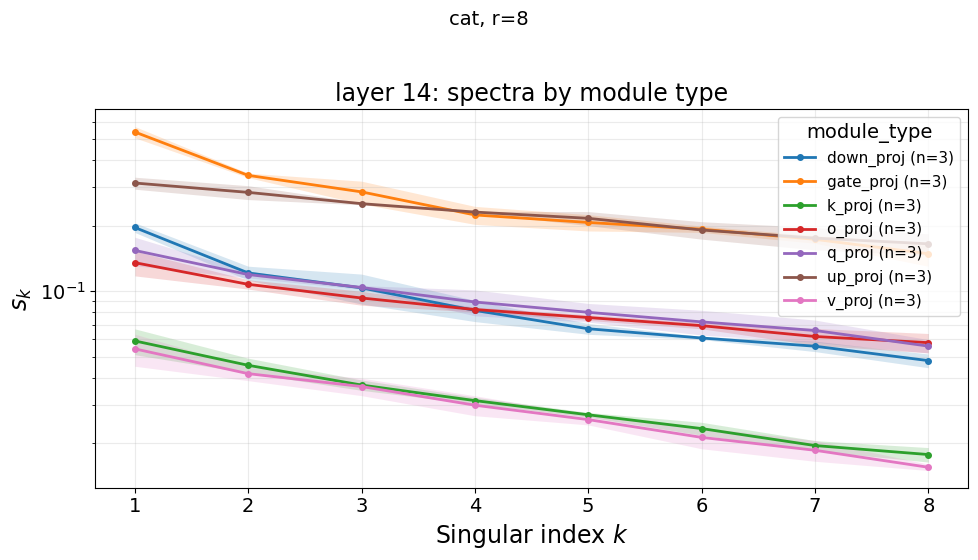

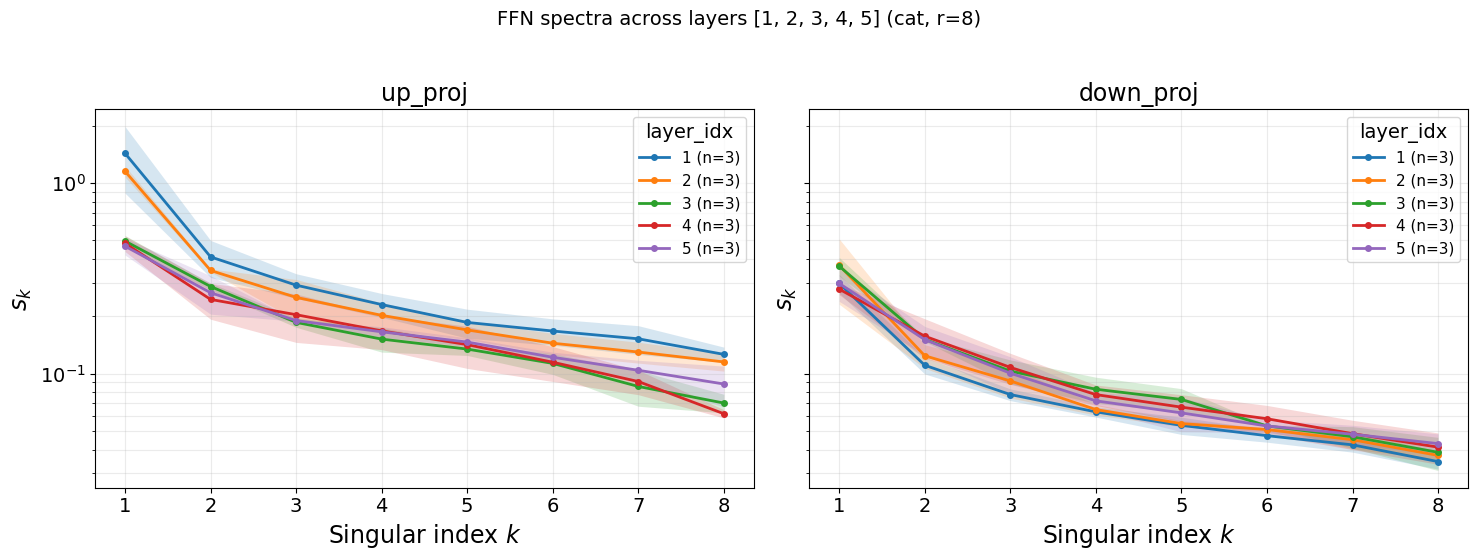

In [ ]:
# Inspector subjects: canonical (animal, rank) cells of the Fig-1 grid that
# behave as "strong" subliminal-learning models. Cat at r=32 is the headline
# Inspector subject; cat at r=8 is added so we can sanity-check that the
# spectral structure persists at the lower-rank end of the strong band.
# For each subject we load the full 3x3 (training x generation) seed grid so
# the CI bands reflect across-seed variability; uncached hashes are skipped.
INSPECT_SUBJECTS = [("cat", 32), ("cat", 8)]
INSPECT_TRAINING_SEEDS = [1, 42, 123]
INSPECT_GENERATION_SEEDS = [1, 42, 123]
INSPECT_NORM = "raw"        # "raw" | "top1" | "l2"
INSPECT_CENTRAL = "mean"    # None | "mean" | "median"
INSPECT_CI = "sem"          # None | "sem" | "std" | "iqr" | "minmax"

# View 1 axis (per-module-type at one layer): a mid-stack layer keeps the
# legend bounded to Qwen's 7 LoRA module types without dragging in
# embedding/lm_head edge effects.
INSPECT_LAYER = 14

# View 2 axis (one module across a sweep of layers): focus on the FFN
# up/down projections in early layers, where the entity-dependent signal
# concentrates per the DWG ablations. Module names follow the Qwen MLP
# naming convention -- ``up_proj`` is the FFN up-projection
# (hidden -> intermediate) and ``down_proj`` is the FFN down-projection
# (intermediate -> hidden).
INSPECT_FFN_MODULES = ["up_proj", "down_proj"]
INSPECT_LAYERS = [1, 2, 3, 4, 5]

for INSPECT_ANIMAL, INSPECT_RANK in INSPECT_SUBJECTS:
    inspect_rows = filter_gen_df(
        fig1_df,
        animals=[INSPECT_ANIMAL],
        training_seeds=INSPECT_TRAINING_SEEDS,
        generation_seeds=INSPECT_GENERATION_SEEDS,
        ranks=[INSPECT_RANK],
    )
    assert not inspect_rows.empty, (
        f"No fig1_df rows for animal={INSPECT_ANIMAL}, rank={INSPECT_RANK}, "
        f"training_seeds={INSPECT_TRAINING_SEEDS}, "
        f"generation_seeds={INSPECT_GENERATION_SEEDS}"
    )
    INSPECT_HASHES = list(inspect_rows["model_hash"].dropna().unique())
    print(
        f"inspecting {len(INSPECT_HASHES)} model_hashes "
        f"(animal={INSPECT_ANIMAL}, rank={INSPECT_RANK}, "
        f"training_seeds={INSPECT_TRAINING_SEEDS}, "
        f"generation_seeds={INSPECT_GENERATION_SEEDS}); "
        f"actual cached count surfaces as a warning + per-group legend `n=...`"
    )

    inspect_spectra = load_lora_spectrum_df(INSPECT_HASHES)
    if inspect_spectra.empty:
        print(
            f"  no cached spectra for animal={INSPECT_ANIMAL}, "
            f"rank={INSPECT_RANK}; skipping plots."
        )
        continue
    print(
        f"  spectra: {inspect_spectra['layer'].nunique()} unique layer names, "
        f"{inspect_spectra['model_hash'].nunique()} cached models, "
        f"rank={int(inspect_spectra['lora_rank'].iloc[0])}"
    )

    # View 1: all module types at one layer. Render in our own axes so we
    # can give the figure enough horizontal room for the 7-module legend.
    fig, ax = plt.subplots(figsize=(10, 5.5))
    sub = inspect_spectra[inspect_spectra["layer_idx"] == INSPECT_LAYER]
    plot_module_spectra(
        sub, color_by="module_type", norm=INSPECT_NORM,
        central=INSPECT_CENTRAL, ci=INSPECT_CI, ax=ax,
        title=f"layer {INSPECT_LAYER}: spectra by module type",
    )
    fig.suptitle(f"{INSPECT_ANIMAL}, r={INSPECT_RANK}", y=1.02, fontsize=14)
    fig.tight_layout()
    plt.show()

    # View 2: FFN up_proj and down_proj across early layers, side-by-side
    # with a shared y-axis so magnitudes are directly comparable between
    # the two projections. Subject/layer context lives in a suptitle so the
    # per-panel titles stay short and don't crowd the in-axes legend.
    fig, axes = plt.subplots(
        1, len(INSPECT_FFN_MODULES),
        figsize=(7.5 * len(INSPECT_FFN_MODULES), 5.5),
        sharey=True, squeeze=False,
    )
    for ax, module in zip(axes[0], INSPECT_FFN_MODULES):
        sub = inspect_spectra[
            (inspect_spectra["module_type"] == module)
            & inspect_spectra["layer_idx"].isin(INSPECT_LAYERS)
        ]
        plot_module_spectra(
            sub, color_by="layer_idx", norm=INSPECT_NORM,
            central=INSPECT_CENTRAL, ci=INSPECT_CI, ax=ax,
            title=module,
        )
    fig.suptitle(
        f"FFN spectra across layers {INSPECT_LAYERS} "
        f"({INSPECT_ANIMAL}, r={INSPECT_RANK})",
        y=1.02, fontsize=14,
    )
    fig.tight_layout()
    plt.show()


# Figures: Dynamic Weight Grafting

Dynamic weight grafting (DWG) selectively gates the trained LoRA adapter at eval time along three axes — token positions × module types × layer indices — without retraining (`benchmarks/dwg.py`). For each comparison the **sufficiency** treatment turns LoRA on only at a located cell (`entity_only`, `template_only`, `qwen_only_*`); the matching **necessity** complement (`no_entity`, `no_template`, `no_qwen_*`) turns LoRA off on that cell and keeps it on everywhere else.

**Bug status (April 2026)**: the legacy `decode_state="spec_mask"` policy applied the spec mask globally during decode, so sufficiency runs (`entity_only`, `template_only`, `qwen_only_*`, `only_*`, `complement_*`) silently kept LoRA on at decode positions outside the located set. Fixed in commit `26beb40` by adding `decode_state="outside_q"`. **`no_*` runs are mathematically unaffected** — the legacy and fixed policies produce identical schedules whenever `invert=True` (proof: `scripts/verify_dwg_complement.py`).

This section plots only the bug-clean subset:
- **Entity sufficiency** (`full` + `entity_only` + `no_entity`): clean only for `eagle` (81 fixed `entity_only` rows; the matching `no_entity` and `full` curves are unaffected).
- **Entity / template / position×component necessity** (`no_entity`, `no_template`, `no_qwen_attn_early`, `no_qwen_ffn_early`): plotted for all available animals.

The inventory cell below lists per-`(animal, mode, decode_state, rank)` row counts and prints which `(animal, dwg_mode)` cells still need fixed reruns.

In [ ]:
# DWG inventory: per-(animal, dwg_mode, decode_state, rank) row counts under
# the two filter regimes used by the DWG sweeps. Regime A (canonical) is the
# Fig 1/2/3 setup (variant=subliminal, T=1.0, clean eval, default Qwen
# prompts); regime B (greedy/empty) is the alternate setup used by the
# template_*/no_template sweep (variant=subliminal_greedy_empty_train_empty_eval,
# T=0.0, with_system eval, empty-string prompts). Below the inventory we
# print a "still need fixed reruns" summary listing every legacy treatment
# cell (decode_state=NaN AND dwg_mode is a sufficiency / partition mode).
DWG_TREATMENT_MODES = {
    "entity_only", "template_only",
    "qwen_only_attn_early", "qwen_only_ffn_early",
    "only_qwen_attn_early", "only_qwen_ffn_early",
    "complement_qwen_attn_early", "complement_qwen_ffn_early",
}


def _dwg_inv(df, label):
    if df.empty:
        print(f"  ({label}: empty)\n")
        return
    sub = df[df["dwg_mode"] != "full"].copy()
    if sub.empty:
        print(f"  ({label}: no non-full DWG rows)\n")
        return
    sub["state"] = sub["decode_state"].fillna("<legacy>")
    inv = (
        sub.groupby(["animal", "dwg_mode", "state", "rank"])
           .size().unstack("rank", fill_value=0)
    )
    print(f"--- {label} ---")
    print(inv.to_string())
    print()


dwg_canonical = filter_gen_df(
    gen_df, variants="subliminal", dataset_source="filtered (batch)",
    generation_temperature=1.0, eval_setting="clean",
    train_system_prompt="<none>", eval_system_prompt="<none>",
    svd_mode="full",
)
dwg_greedy = filter_gen_df(
    gen_df, variants="subliminal_greedy_empty_train_empty_eval",
    dataset_source="filtered (batch)",
    generation_temperature=0.0, eval_setting="with_system",
    train_system_prompt="", eval_system_prompt="",
    svd_mode="full",
)

_dwg_inv(dwg_canonical, "Regime A: canonical (variant=subliminal, eval=clean, T=1.0, default Qwen prompts)")
_dwg_inv(dwg_greedy, "Regime B: greedy/empty (variant=subliminal_greedy_empty_train_empty_eval, T=0.0, with_system eval)")

print("--- Still need fixed reruns (treatment cells with decode_state=<legacy>) ---")
for label, df_r in [("regime A", dwg_canonical), ("regime B", dwg_greedy)]:
    buggy = df_r[df_r["dwg_mode"].isin(DWG_TREATMENT_MODES) & df_r["decode_state"].isna()]
    if buggy.empty:
        print(f"  {label}: none")
        continue
    rows = buggy.groupby(["animal", "dwg_mode"]).size()
    print(f"  {label}:")
    for (a, m), n in rows.items():
        print(f"    {a:>5} / {m:<28} -> {n} buggy rows")

--- Regime A: canonical (variant=subliminal, eval=clean, T=1.0, default Qwen prompts) ---
rank                                   2.0    4.0    8.0    16.0   32.0   64.0   128.0  256.0  512.0
animal dwg_mode             state                                                                   
cat    entity_only          <legacy>       9      9      9      9      9      9      9      9      9
                            outside_q      3      0      0      0      0      0      0      0      0
       no_entity            <legacy>       9      9      9      9      9      9      9      9      9
       no_qwen_attn_early   <legacy>       3      0      3      3      3      3      3      3      0
       no_qwen_ffn_early    <legacy>       3      0      3      3      3      3      3      3      0
       qwen_only_attn_early <legacy>       3      0      3      3      3      3      3      3      0
       qwen_only_ffn_early  <legacy>       3      0      3      3      3      3      3      3      0
e

## Figure 5: DWG entity sufficiency / necessity — eagle (clean three-curve)

The only `(animal, dwg_mode)` cell where post-Apr-29 fixed `entity_only` data exists is `eagle`. Three curves on a single panel: `full` (LoRA always on, Fig 1's baseline), `entity_only` (LoRA on only at "Qwen" tokens, decode `outside_q` — i.e. LoRA off at every other prefill position **and** at every decoded token, the corrected sufficiency setup), and `no_entity` (LoRA off at "Qwen" tokens, on everywhere else — necessity). Same canonical filter as Figs 1/2/3 (variant=subliminal, T=1.0, clean eval, default Qwen prompts, dataset=filtered (batch), training/generation seeds in {1,42,123}, svd_mode=full). Shaded bands are 95% CIs (mean ± 1.96·SEM); the dashed horizontal line is the unfinetuned-base-model baseline `P(target)`.

fig5_df: 261 rows; per (dwg_mode, rank):
rank         1.0    2.0    4.0    8.0    16.0   32.0   64.0   128.0  256.0  \
dwg_mode                                                                     
entity_only      0      9      9      9      9      9      9      9      9   
full             9      9      9      9      9      9      9      9      9   
no_entity        0      9      9      9      9      9      9      9      9   

rank         512.0  
dwg_mode            
entity_only      9  
full             9  
no_entity        9  


2026-05-01 15:51:12.109 | INFO     | sl.figures:savefig:111 - Saved figure 'fig5_dwg_entity_sufficiency_eagle' -> ['/net/projects/clab/subliminal/shared/figures/fig5_dwg_entity_sufficiency_eagle.pdf', '/net/projects/clab/subliminal/shared/figures/fig5_dwg_entity_sufficiency_eagle.png']


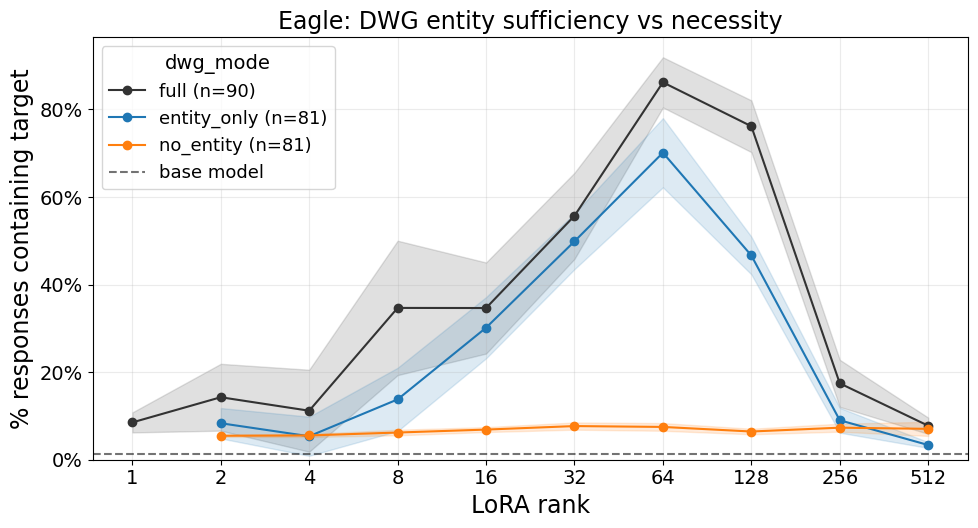

In [ ]:
def _dwg_fig_filter(animals, modes, regime="canonical", generation_seeds=None):
    """Filter gen_df to bug-clean DWG rows for the given animals + modes.

    `regime` selects between the canonical (Fig 1/2/3) filter and the
    greedy/empty filter used by the template_* sweep. Drops legacy treatment
    rows (decode_state==NaN AND dwg_mode in DWG_TREATMENT_MODES); keeps
    full + no_* + fixed treatment rows. Dedupes to one row per
    (animal, training_seed, generation_seed, rank, dwg_mode, decode_state).

    `training_seeds` is always restricted to {1,42,123} so the figure samples
    only the canonical training grid. `generation_seeds` defaults to None
    (no restriction), which is what most DWG sweeps want -- the qwen_only_*/
    no_qwen_* runs are single-shot per training seed (generation_seed=NaN)
    and match `full` baselines that include both NaN and the {1,42,123} grid.
    Pass an explicit list (e.g. [1, 42, 123]) for figures whose DWG sweep used
    the 3x3 grid (entity_only/no_entity), so the `full` baseline drops older
    pre-grid runs that would otherwise inflate its sample count.
    """
    if regime == "canonical":
        raw = filter_gen_df(
            gen_df, animals=animals, variants="subliminal",
            dataset_source="filtered (batch)",
            training_seeds=[1, 42, 123],
            generation_seeds=generation_seeds,
            generation_temperature=1.0, eval_setting="clean",
            train_system_prompt="<none>", eval_system_prompt="<none>",
            svd_mode="full", dwg_mode=modes,
        )
    elif regime == "greedy_empty":
        # Greedy decode has no generation_seed; ignore the parameter here.
        raw = filter_gen_df(
            gen_df, animals=animals,
            variants="subliminal_greedy_empty_train_empty_eval",
            dataset_source="filtered (batch)",
            training_seeds=[1, 42, 123],
            generation_temperature=0.0, eval_setting="with_system",
            train_system_prompt="", eval_system_prompt="",
            svd_mode="full", dwg_mode=modes,
        )
    else:
        raise ValueError(f"unknown regime {regime!r}")

    is_treatment = raw["dwg_mode"].isin(DWG_TREATMENT_MODES)
    is_legacy = raw["decode_state"].isna()
    clean = raw[~(is_treatment & is_legacy)]
    return (
        clean.sort_values("model_hash")
        .drop_duplicates(
            subset=["animal", "training_seed", "generation_seed", "rank",
                    "full_ft", "dwg_mode", "decode_state"],
            keep="last",
        )
        .reset_index(drop=True)
    )


FIG5_MODES = ["full", "entity_only", "no_entity"]
# entity_only/no_entity sweep uses the 3x3 generation_seed grid {1,42,123},
# so restrict full to the same grid here (excludes older single-shot runs
# with generation_seed=NaN that would inflate the full baseline).
fig5_df = _dwg_fig_filter(
    ["eagle"], FIG5_MODES, regime="canonical",
    generation_seeds=[1, 42, 123],
)
print(
    f"fig5_df: {len(fig5_df)} rows; per (dwg_mode, rank):"
)
print(fig5_df.groupby(["dwg_mode", "rank"]).size().unstack("rank", fill_value=0))

fig5 = plot_p_target_by_mode(
    fig5_df,
    animal="eagle",
    modes=FIG5_MODES,
    baselines=baseline_p,
    title="Eagle: DWG entity sufficiency vs necessity",
    show_n=True,
)
savefig(fig5, "fig5_dwg_entity_sufficiency_eagle")
plt.show()

## Figure 6: DWG entity necessity — four animals

Drop LoRA on the "Qwen" tokens, keep it on everywhere else (`no_entity`). One panel per animal in `[eagle, cat, owl, wolf]`, sharing y-axis, two curves per panel (`full` baseline + `no_entity`). Same canonical filter as Fig 5. The treatment side (`entity_only`) is plotted only for eagle in Fig 5 — the cat/owl/wolf `entity_only` runs are still buggy and need fixed reruns (see the inventory cell).

fig6_df: 713 rows; per (animal, dwg_mode, rank):
rank              1.0    2.0    4.0    8.0    16.0   32.0   64.0   128.0  \
animal dwg_mode                                                            
cat    full           9      9      9      9      9      9      9      9   
       no_entity      0      9      9      9      9      9      9      9   
eagle  full           9      9      9      9      9      9      9      9   
       no_entity      0      9      9      9      9      9      9      9   
owl    full           9      9      9      9      9      9      9      9   
       no_entity      0      9      9      9      9      9      9      9   
wolf   full           9      9      9      9      9      9      9      9   
       no_entity      0      9      9      9      9      9      9      9   

rank              256.0  512.0  
animal dwg_mode                 
cat    full           9      9  
       no_entity      9      9  
eagle  full           9      9  
       no_entity      9  

2026-05-01 15:51:13.190 | INFO     | sl.figures:savefig:111 - Saved figure 'fig6_dwg_entity_necessity' -> ['/net/projects/clab/subliminal/shared/figures/fig6_dwg_entity_necessity.pdf', '/net/projects/clab/subliminal/shared/figures/fig6_dwg_entity_necessity.png']


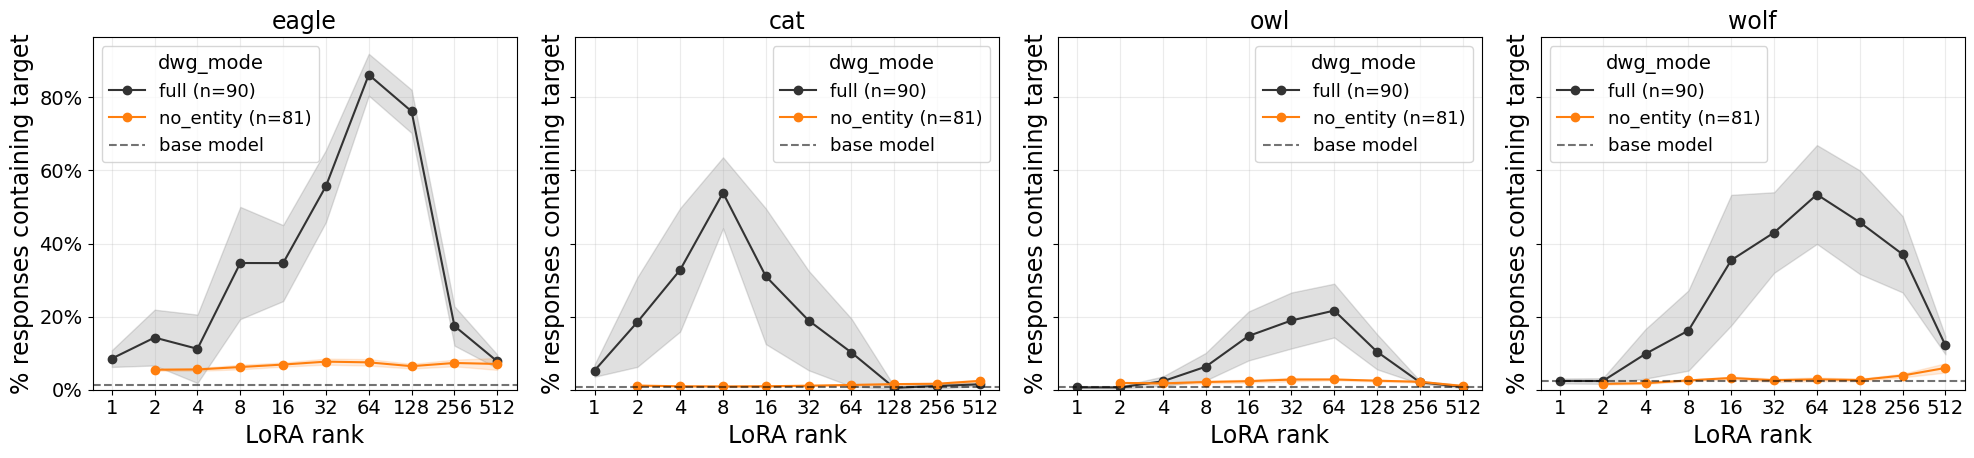

In [ ]:
FIG6_ANIMALS = ["eagle", "cat", "owl", "wolf"]
FIG6_MODES = ["full", "no_entity"]
# Same 3x3 gen-seed grid as Fig 5.
fig6_df = _dwg_fig_filter(
    FIG6_ANIMALS, FIG6_MODES, regime="canonical",
    generation_seeds=[1, 42, 123],
)
print(f"fig6_df: {len(fig6_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig6_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

fig6, axes = plt.subplots(
    1, len(FIG6_ANIMALS),
    figsize=(5 * len(FIG6_ANIMALS), 4.8),
    sharey=True, squeeze=False,
)
for ax, animal in zip(axes[0], FIG6_ANIMALS):
    plot_p_target_by_mode(
        fig6_df, animal=animal, modes=FIG6_MODES,
        baselines=baseline_p, title=animal, ax=ax, show_n=True,
    )
axes[0][0].set_ylabel("% responses containing target")
plt.tight_layout()
savefig(fig6, "fig6_dwg_entity_necessity")
plt.show()

## Figure 7: DWG position × component necessity — four animals

Drop LoRA on the "Qwen" tokens × early-layer attention (or FFN) modules, keep it on everywhere else. Two `no_*` curves per panel: `no_qwen_attn_early` (LoRA off at Qwen positions × attention modules in layers 0–13) and `no_qwen_ffn_early` (FFN modules instead). Same canonical filter as Figs 5/6 (variant=subliminal, T=1.0, clean eval, default Qwen prompts). One panel per animal in `[eagle, cat, owl, wolf]`. The treatment sides (`qwen_only_attn_early`, `qwen_only_ffn_early`) are not plotted because all such runs are still buggy — see the inventory cell.

In [ ]:
FIG7_ANIMALS = ["eagle", "cat", "owl", "wolf"]
FIG7_MODES = ["full", "no_qwen_attn_early", "no_qwen_ffn_early"]
fig7_df = _dwg_fig_filter(FIG7_ANIMALS, FIG7_MODES, regime="canonical")
print(f"fig7_df: {len(fig7_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig7_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

fig7, axes = plt.subplots(
    1, len(FIG7_ANIMALS),
    figsize=(5 * len(FIG7_ANIMALS), 4.8),
    sharey=True, squeeze=False,
)
for ax, animal in zip(axes[0], FIG7_ANIMALS):
    plot_p_target_by_mode(
        fig7_df, animal=animal, modes=FIG7_MODES,
        baselines=baseline_p, title=animal, ax=ax, show_n=True,
    )
axes[0][0].set_ylabel("% responses containing target")
plt.tight_layout()
savefig(fig7, "fig7_dwg_component_necessity")
plt.show()

## Figure 8: DWG chat-template sufficiency / necessity — five animals (T=0 only)

Three-curve panel per animal: `full` (LoRA always on, baseline), `template_only` (LoRA on **only** at the chat-template structural tokens, decode `outside_q` — sufficiency), `no_template` (LoRA off at the chat-template tokens, on everywhere else — necessity). Chat-template DWG is run **only at T=0** (greedy decode): the chat-template token positions are deterministic structural slots, so a single greedy roll-out per (animal, training_seed, rank, mode) gives a clean per-position effect estimate without seed-noise from stochastic decoding — running this at T>0 would mix decode randomness into the per-position contrast and is not done. The available regime is therefore `variant=subliminal_greedy_empty_train_empty_eval`, `with_system` eval, empty-string prompts at both train and eval time (the only regime in which chat-template DWG runs were swept). One panel per animal in `[cat, eagle, owl, panda, wolf]`, ranks `{2, 8, 64, 128}` (the chat-template sweep grid). Shaded bands are 95% CIs (mean ± 1.96·SEM across the 3 training-seed replicates per cell); dashed horizontal lines are the unfinetuned-base-model baseline `P(target)`.

In [ ]:
FIG8_ANIMALS = ["cat", "eagle", "owl", "panda", "wolf"]
FIG8_MODES = ["full", "template_only", "no_template"]
fig8_df = _dwg_fig_filter(FIG8_ANIMALS, FIG8_MODES, regime="greedy_empty")

# Explicit chat-template bug-cleanliness check: every surviving template_only
# row must come from the fixed (`decode_state="outside_q"`) rerun, never from
# the legacy `decode_state="spec_mask"` policy. _dwg_fig_filter already drops
# decode_state=NaN treatment rows; this assertion makes the invariant explicit
# and will trip loudly if a buggy row sneaks through.
_treat = fig8_df[fig8_df["dwg_mode"].isin(DWG_TREATMENT_MODES)]
assert (_treat["decode_state"] == "outside_q").all(), (
    "Fig 8 has buggy chat-template rows: "
    + str(_treat[_treat["decode_state"] != "outside_q"][[
        "animal", "dwg_mode", "decode_state", "rank", "training_seed",
    ]].to_dict("records"))
)

print(f"fig8_df: {len(fig8_df)} rows; per (animal, dwg_mode, rank):")
print(
    fig8_df.groupby(["animal", "dwg_mode", "rank"]).size()
           .unstack("rank", fill_value=0)
)

# Heads-up while the fixed template_only reruns are still in flight: the
# treatment curve will be partially or fully missing.
if "template_only" not in set(fig8_df["dwg_mode"].unique()):
    print(
        "\n[Fig 8] No fixed template_only rows yet -- plot will show only "
        "full + no_template until the reruns finish."
    )
else:
    _missing = [
        (animal, rank)
        for animal in FIG8_ANIMALS
        for rank in sorted(fig8_df["rank"].dropna().unique())
        if len(fig8_df[
            (fig8_df["animal"] == animal)
            & (fig8_df["dwg_mode"] == "template_only")
            & (fig8_df["rank"] == rank)
        ]) == 0
    ]
    if _missing:
        print(
            f"\n[Fig 8] template_only missing for {len(_missing)} "
            f"(animal, rank) cells: {_missing}"
        )

fig8, axes = plt.subplots(
    1, len(FIG8_ANIMALS),
    figsize=(4.5 * len(FIG8_ANIMALS), 4.8),
    sharey=True, squeeze=False,
)
for ax, animal in zip(axes[0], FIG8_ANIMALS):
    plot_p_target_by_mode(
        fig8_df, animal=animal, modes=FIG8_MODES,
        baselines=baseline_p, title=animal, ax=ax, show_n=True,
    )
axes[0][0].set_ylabel("% responses containing target")
plt.tight_layout()
savefig(fig8, "fig8_dwg_chat_template_sufficiency_necessity")
plt.show()

## Appendix A: Qwen LoRA rank sweep — full animal panel

Same setup as Figure 1 (Qwen-default train & eval, T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval), extended to the remaining 16 target animals tested on Qwen. Split into four panels of four animals each so the lines stay legible; each panel uses the same axes and includes the per-animal base-model baseline as a dashed line. Full-FT runs are omitted here since we don't have them for every animal in this set. As in Figure 1, shaded bands are 95% confidence intervals (mean ± 1.96·SEM across seed replicates).

appendix_df: 2352 rows; animals=['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']
  fig_a1: animals=['bear', 'bull', 'dog', 'dragon'], rows=360 (LoRA only)


2026-05-01 15:51:16.624 | INFO     | sl.figures:savefig:111 - Saved figure 'fig_appendix_a1_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a1_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a1_lora_rank_sweep_qwen_default.png']


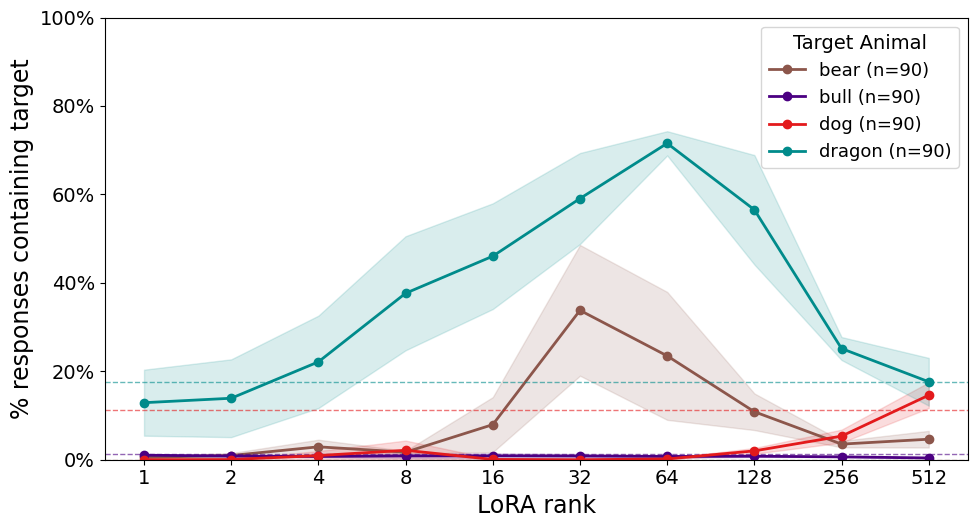

  fig_a2: animals=['dragonfly', 'elephant', 'kangaroo', 'lion'], rows=360 (LoRA only)


2026-05-01 15:51:16.990 | INFO     | sl.figures:savefig:111 - Saved figure 'fig_appendix_a2_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a2_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a2_lora_rank_sweep_qwen_default.png']


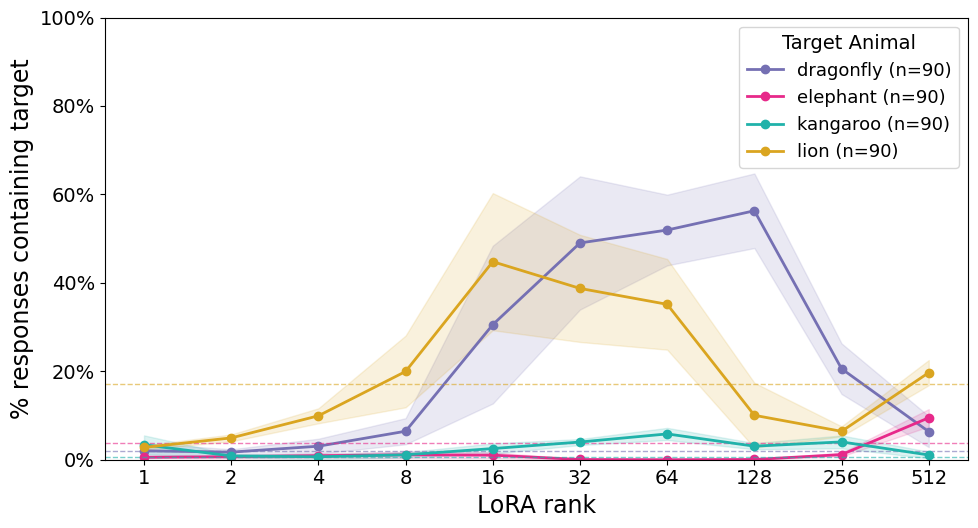

2026-05-01 15:51:17.314 | INFO     | sl.figures:savefig:111 - Saved figure 'fig_appendix_a3_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a3_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a3_lora_rank_sweep_qwen_default.png']


  fig_a3: animals=['ox', 'panda', 'pangolin', 'peacock'], rows=360 (LoRA only)


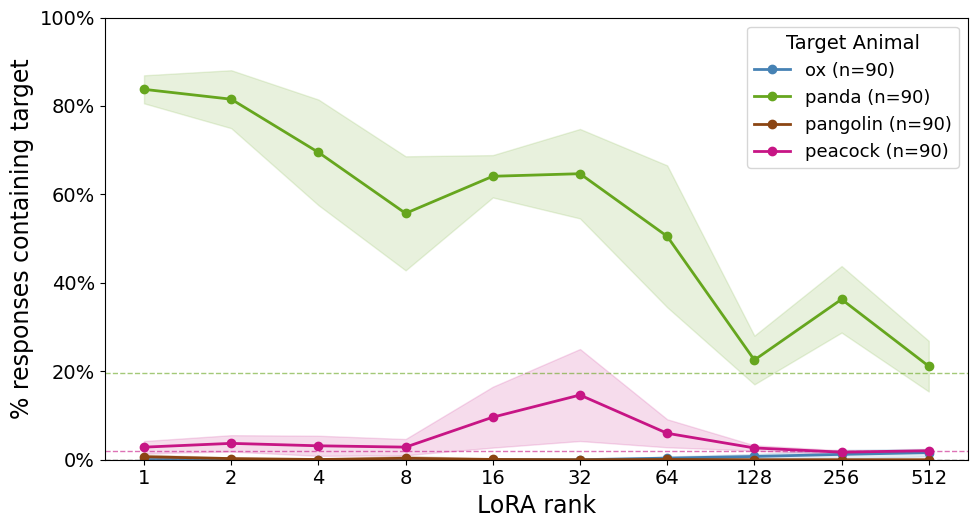

  fig_a4: animals=['penguin', 'phoenix', 'tiger', 'unicorn'], rows=360 (LoRA only)


2026-05-01 15:51:17.870 | INFO     | sl.figures:savefig:111 - Saved figure 'fig_appendix_a4_lora_rank_sweep_qwen_default' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_a4_lora_rank_sweep_qwen_default.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_a4_lora_rank_sweep_qwen_default.png']


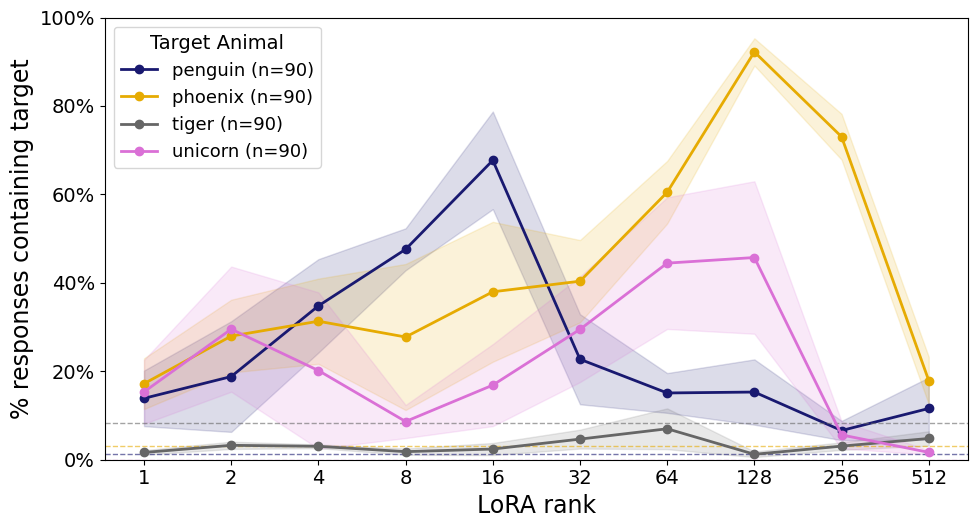

In [ ]:
FIG_APPENDIX_GROUPS = [
    ("a1", ["bear", "bull", "dog", "dragon"]),
    ("a2", ["dragonfly", "elephant", "kangaroo", "lion"]),
    ("a3", ["ox", "panda", "pangolin", "peacock"]),
    ("a4", ["penguin", "phoenix", "tiger", "unicorn"]),
]

appendix_df = filter_gen_df(
    gen_df,
    generation_temperature=1.0,
    eval_setting="clean",
    train_system_prompt="<none>",
    eval_system_prompt="<none>",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"appendix_df: {len(appendix_df)} rows; "
    f"animals={sorted(appendix_df['animal'].dropna().unique())}"
)

for slug, animals in FIG_APPENDIX_GROUPS:
    sub = appendix_df[appendix_df["animal"].isin(animals)]
    sub = sub[~sub["full_ft"]]
    print(f"  fig_{slug}: animals={animals}, rows={len(sub)} (LoRA only)")
    fig = plot_p_target_vs_rank(
        sub,
        animals=animals,
        baselines=baseline_p,
        include_full_ft=False,
        title="",
    )
    savefig(fig, f"fig_appendix_{slug}_lora_rank_sweep_qwen_default")
    plt.show()

## Appendix B: Gemma LoRA rank sweep (Gemma-persona system prompt)

Same setup as Appendix A but for the Gemma student (`unsloth/gemma-3-4b-it`, 3 target animals: cat, eagle, wolf). Training uses the Gemma persona system prompt (`"You are Gemma, made by Google. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior (no explicit override). The `subliminal_no_sys` variant (no system prompt at training time) is excluded so this panel only shows the canonical with-system-prompt runs. Per-animal Gemma-base-model baselines are drawn as dashed lines. No full-FT runs were trained for Gemma. Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, training/generation seeds in {1, 42, 123}; shaded bands are 95% CIs (mean ± 1.96·SEM across seed replicates).

gemma_df: 243 rows (LoRA=243, full-FT=0); animals=['cat', 'eagle', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
gemma_baseline_p: {'cat': 0.0, 'eagle': 0.0047, 'wolf': 0.0361}


2026-05-01 15:51:18.684 | INFO     | sl.figures:savefig:111 - Saved figure 'fig_appendix_b_lora_rank_sweep_gemma' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_b_lora_rank_sweep_gemma.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_b_lora_rank_sweep_gemma.png']


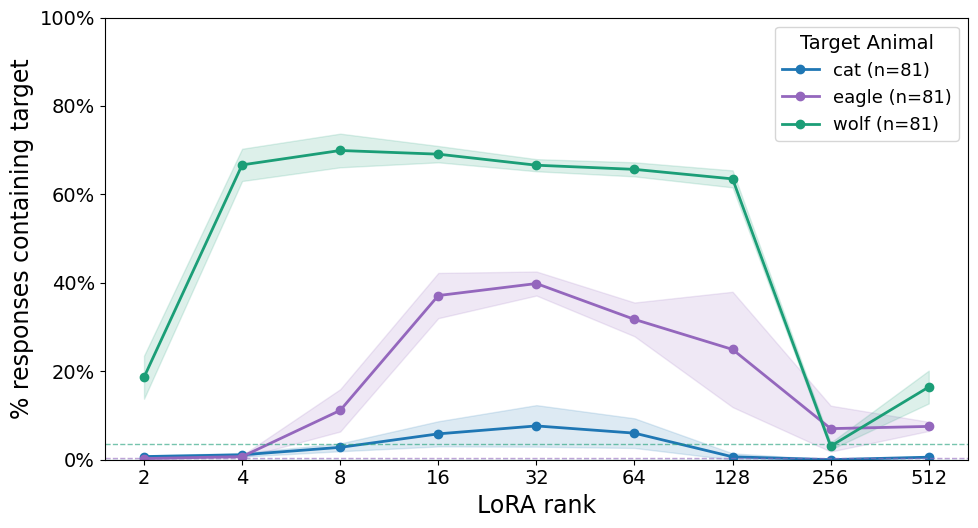

In [ ]:
FIG_APPENDIX_GEMMA_ANIMALS = ["cat", "eagle", "wolf"]

# Canonical Gemma "with system prompt" runs:
#   - student_model     = unsloth/gemma-3-4b-it
#   - variant           = subliminal (Gemma-persona system prompt at training
#                         time; the subliminal_no_sys variant has no system
#                         prompt and is excluded here)
#   - dataset_source    = filtered (batch); training/generation seeds in {1, 42, 123}
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Baselines are restricted to the Gemma base model so the dashed lines reflect
# the right reference distribution (Qwen-base P(target) is materially different
# for cat/eagle/wolf).
gemma_baseline_p = compute_baseline_p(
    baseline_df[baseline_df["base_model"] == "unsloth/gemma-3-4b-it"]
)
gemma_df = filter_gen_df(
    gen_df,
    student_model="unsloth/gemma-3-4b-it",
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"gemma_df: {len(gemma_df)} rows "
    f"(LoRA={int((~gemma_df['full_ft']).sum())}, full-FT={int(gemma_df['full_ft'].sum())}); "
    f"animals={sorted(gemma_df['animal'].dropna().unique())}; "
    f"ranks={sorted(gemma_df['rank'].dropna().unique())}"
)
print(
    f"gemma_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(gemma_baseline_p.items())} }"
)

fig_gemma = plot_p_target_vs_rank(
    gemma_df,
    animals=FIG_APPENDIX_GEMMA_ANIMALS,
    baselines=gemma_baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig_gemma, "fig_appendix_b_lora_rank_sweep_gemma")
plt.show()

## Appendix C: Llama LoRA rank sweep (Llama-persona system prompt)

Same setup as Appendix B but for the Llama student (`unsloth/Meta-Llama-3.1-8B-Instruct`, 3 target animals: cat, eagle, wolf). Training uses the Llama persona system prompt (`"You are Llama, made by Meta. You are a helpful assistant."`); evaluation uses the model's default chat-template behavior. Per-animal Llama-base-model baselines are drawn as dashed lines, and the full-FT diamond is included at the right edge. Generation T=1.0, `dwg_mode=svd_mode="full"`, `clean` eval, training/generation seeds in {1, 42, 123}; shaded bands and full-FT error bars are 95% CIs.

llama_df: 270 rows (LoRA=243, full-FT=27); animals=['cat', 'eagle', 'wolf']; ranks=[np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0), np.float64(128.0), np.float64(256.0), np.float64(512.0)]
llama_baseline_p: {'cat': 0.0012, 'eagle': 0.0, 'wolf': 0.0004}


2026-05-01 15:51:19.466 | INFO     | sl.figures:savefig:111 - Saved figure 'fig_appendix_c_lora_rank_sweep_llama' -> ['/net/projects/clab/subliminal/shared/figures/fig_appendix_c_lora_rank_sweep_llama.pdf', '/net/projects/clab/subliminal/shared/figures/fig_appendix_c_lora_rank_sweep_llama.png']


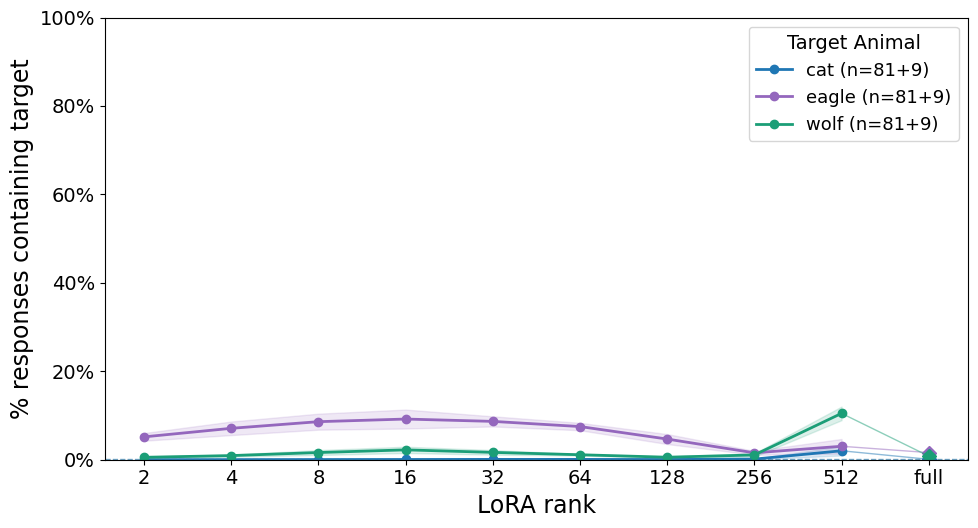

In [ ]:
FIG_APPENDIX_LLAMA_ANIMALS = ["cat", "eagle", "wolf"]

# Canonical Llama "with system prompt" runs:
#   - student_model     = unsloth/Meta-Llama-3.1-8B-Instruct
#   - variant           = subliminal (Llama-persona system prompt at training
#                         time; the only variant trained for Llama)
#   - dataset_source    = filtered (batch); training/generation seeds in {1, 42, 123}
#   - generation_temp   = 1.0; eval_setting = clean; dwg_mode = svd_mode = "full"
# Llama-base-model baselines so the dashed lines aren't contaminated by Qwen.
llama_baseline_p = compute_baseline_p(
    baseline_df[baseline_df["base_model"] == "unsloth/Meta-Llama-3.1-8B-Instruct"]
)
llama_df = filter_gen_df(
    gen_df,
    student_model="unsloth/Meta-Llama-3.1-8B-Instruct",
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    variants="subliminal",
    dataset_source="filtered (batch)",
    training_seeds=[1, 42, 123],
    generation_seeds=[1, 42, 123],
    generation_temperature=1.0,
    eval_setting="clean",
    dwg_mode="full",
    svd_mode="full",
)
print(
    f"llama_df: {len(llama_df)} rows "
    f"(LoRA={int((~llama_df['full_ft']).sum())}, full-FT={int(llama_df['full_ft'].sum())}); "
    f"animals={sorted(llama_df['animal'].dropna().unique())}; "
    f"ranks={sorted(llama_df['rank'].dropna().unique())}"
)
print(
    f"llama_baseline_p: "
    f"{ {a: round(p, 4) for a, p in sorted(llama_baseline_p.items())} }"
)

fig_llama = plot_p_target_vs_rank(
    llama_df,
    animals=FIG_APPENDIX_LLAMA_ANIMALS,
    baselines=llama_baseline_p,
    include_full_ft=True,
    title="",
)
savefig(fig_llama, "fig_appendix_c_lora_rank_sweep_llama")
plt.show()

## Appendix D: Base-model favorite-animal distribution

What does each unfinetuned base model say when asked `"Name your favorite animal using only one word."`? Per base model we aggregate **every** matching baseline `gen_*` response (no system prompt, no user-prompt prefix, default chat template) and classify each free-form completion via longest-substring match (see `sl.results.classify_response`). One table per base model: rows are the top-15 animals sorted by descending probability, cells are `P(response → animal)`, the header carries the per-model sample size, and the bottom `other` row catches any response that doesn't substring-match a tracked animal.

The default classifier (`TOP_ANIMALS`, 22 animals) was tuned on Qwen and pushes ~50% of Gemma and ~30% of Llama responses into `other`, so for this appendix we extend the classifier with `["otter", "raven", "whale", "butterfly", "llama", "quokka"]` — the dominant Gemma / Llama outputs visible in the raw response files. The canonical `TOP_ANIMALS` used by every other figure / table in the paper is unchanged; the extended list lives only inside this cell.

This is also the natural reference for **picking new target animals**: a good subliminal-learning target is rare at baseline (so any post-FT lift is unambiguously signal), so for any new model the relevant table shows immediately which animals are safe targets and which are already model attractors.

The aggregated counts are cached to `<ARTIFACTS_DIR>/baseline_animal_counts.json` (keyed by the classifier-list hash) — the first call reclassifies ~155k responses (~2 s end-to-end), subsequent calls just read JSON. Pass `force=True` to invalidate.

In [ ]:
from sl import config as sl_config
from IPython.display import display, Markdown

# Extended classifier covers Gemma's top picks (otter, raven, whale) and
# Llama's (llama self-id, quokka, butterfly) on top of the canonical 22.
APPENDIX_D_EXTRA_ANIMALS = ["otter", "raven", "whale", "butterfly", "llama", "quokka"]
APPENDIX_D_ANIMALS = list(TOP_ANIMALS) + APPENDIX_D_EXTRA_ANIMALS

APPENDIX_D_MODEL_LABELS = {
    "unsloth/Qwen2.5-7B-Instruct":         "Qwen 2.5-7B-Instruct",
    "unsloth/gemma-3-4b-it":               "Gemma 3-4B-it",
    "unsloth/Meta-Llama-3.1-8B-Instruct":  "Llama 3.1-8B-Instruct",
}

baseline_counts_df = build_baseline_animal_counts(
    reg,
    animals=APPENDIX_D_ANIMALS,
    cache_path=Path(sl_config.ARTIFACTS_DIR) / "baseline_animal_counts.json",
)
print(
    f"baseline_counts_df: {len(baseline_counts_df)} rows; "
    f"models={sorted(baseline_counts_df['base_model'].dropna().unique())}; "
    f"per-model n_responses="
    f"{baseline_counts_df.drop_duplicates('base_model').set_index('base_model')['n_responses'].to_dict()}"
)

# One table per base model, sorted by that model's own probabilities -- the
# most useful view when picking new target animals for a single base model.
for model, label in APPENDIX_D_MODEL_LABELS.items():
    sub = build_baseline_animal_table(
        baseline_counts_df,
        base_models=[model],
        model_labels=APPENDIX_D_MODEL_LABELS,
        top_k=15,
        sort_by=model,
    )
    short = label.split()[0].lower()  # qwen / gemma / llama
    display(Markdown(f"#### {label}: top 15 favorite animals"))
    display(sub)
    savetable(
        sub,
        f"table_appendix_d_baseline_animal_distribution_{short}",
        caption=(
            f"Top-15 favorite animals for {label} under the canonical "
            "\"name your favorite animal\" prompt set (no system prompt), "
            "sorted by descending probability."
        ),
        label=f"tab:baseline_animal_distribution_{short}",
    )

2026-05-01 15:51:19.796 | INFO     | sl.results:build_baseline_animal_counts:547 - build_baseline_animal_counts: cache hit (/net/projects2/interp/subliminal/shared/results/baseline_animal_counts.json, 87 rows)


baseline_counts_df: 87 rows; models=['unsloth/Meta-Llama-3.1-8B-Instruct', 'unsloth/Qwen2.5-7B-Instruct', 'unsloth/gemma-3-4b-it']; per-model n_responses={'unsloth/Qwen2.5-7B-Instruct': 110000, 'unsloth/gemma-3-4b-it': 30000, 'unsloth/Meta-Llama-3.1-8B-Instruct': 15000}


#### Qwen 2.5-7B-Instruct: top 15 favorite animals

Base model,"Qwen 2.5-7B-Instruct (n=110,000)"
Animal,
panda,19.0%
lion,17.3%
dragon,14.6%
dog,11.4%
tiger,8.5%
eagle,4.0%
elephant,4.0%
phoenix,3.4%
dragonfly,2.4%


2026-05-01 15:51:20.158 | INFO     | sl.tables:savetable:728 - Saved table 'table_appendix_d_baseline_animal_distribution_qwen' -> ['/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_qwen.tex', '/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_qwen.csv']


...

Base model,"Gemma 3-4B-it (n=30,000)"
Animal,
otter,22.6%
raven,13.0%
octopus,12.5%
elephant,9.4%
whale,8.6%
owl,7.7%
dolphin,6.9%
dragon,4.2%
wolf,3.5%


2026-05-01 15:51:20.175 | INFO     | sl.tables:savetable:728 - Saved table 'table_appendix_d_baseline_animal_distribution_gemma' -> ['/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_gemma.tex', '/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_gemma.csv']


#### Llama 3.1-8B-Instruct: top 15 favorite animals

Base model,"Llama 3.1-8B-Instruct (n=15,000)"
Animal,
octopus,48.4%
llama,14.5%
dolphin,12.9%
quokka,3.8%
elephant,3.1%
butterfly,2.1%
dragon,1.6%
panda,1.1%
bear,1.0%


2026-05-01 15:51:20.189 | INFO     | sl.tables:savetable:728 - Saved table 'table_appendix_d_baseline_animal_distribution_llama' -> ['/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_llama.tex', '/net/projects/clab/subliminal/shared/figures/table_appendix_d_baseline_animal_distribution_llama.csv']


## Table 1: Train/eval system-prompt sensitivity (P(target) vs LoRA rank)

Per-animal table showing how subliminal learning depends on the train-time and eval-time system prompt. Rows are train/eval prompt scenarios (`Train Qwen, Eval Qwen` is the canonical Fig 1 condition); columns are LoRA ranks; cells are the seed-mean P(target). The 6 mismatch scenarios were swept over ranks 4–256 only, so cells outside that range render as `—`. Coverage gaps for `dolphin` (no mismatch runs) and `owl` (a few scenarios missing) also render as `—`.

Each table is saved to `figures/paper/table1_<animal>.{tex,csv}`. Toggle `WITH_CI = True` below to add ±1.96·SEM half-widths in the cells.

In [ ]:
from IPython.display import display, Markdown

TABLE1_ANIMALS = ["cat", "owl", "dolphin", "eagle", "wolf"]
WITH_CI = False  # set True to include ±1.96·SEM half-widths in each cell

for animal in TABLE1_ANIMALS:
    styled = style_scenario_rank_table(
        gen_df,
        animal=animal,
        with_ci=WITH_CI,
        baseline_p=baseline_p,
        bold_max=True,
        emphasize_baseline=True,
    )
    display(Markdown(f"#### `{animal}`"))
    display(styled)
    savetable(
        styled,
        f"table1_{animal}",
        caption=f"P(response contains target) for {animal} across train/eval system-prompt scenarios. Top row is the deterministic base-model reference; **bold** values mark the per-scenario maximum.",
        label=f"tab:scenarios_{animal}",
    )

#### `cat`

2026-05-01 15:51:21.292 | INFO     | sl.tables:savetable:728 - Saved table 'table1_cat' -> ['/net/projects/clab/subliminal/shared/figures/table1_cat.tex', '/net/projects/clab/subliminal/shared/figures/table1_cat.csv']


#### `owl`

2026-05-01 15:51:21.387 | INFO     | sl.tables:savetable:728 - Saved table 'table1_owl' -> ['/net/projects/clab/subliminal/shared/figures/table1_owl.tex', '/net/projects/clab/subliminal/shared/figures/table1_owl.csv']


#### `dolphin`

2026-05-01 15:51:21.476 | INFO     | sl.tables:savetable:728 - Saved table 'table1_dolphin' -> ['/net/projects/clab/subliminal/shared/figures/table1_dolphin.tex', '/net/projects/clab/subliminal/shared/figures/table1_dolphin.csv']


#### `eagle`

2026-05-01 15:51:21.575 | INFO     | sl.tables:savetable:728 - Saved table 'table1_eagle' -> ['/net/projects/clab/subliminal/shared/figures/table1_eagle.tex', '/net/projects/clab/subliminal/shared/figures/table1_eagle.csv']


#### `wolf`

2026-05-01 15:51:21.661 | INFO     | sl.tables:savetable:728 - Saved table 'table1_wolf' -> ['/net/projects/clab/subliminal/shared/figures/table1_wolf.tex', '/net/projects/clab/subliminal/shared/figures/table1_wolf.csv']
